# Урок 4. Без учителя: кластеры и карты эмбеддингов

🎯 **Цели урока**

- проверить текстовые данные на дубликаты и пересечения до любой модели;
- представить отзывы двумя способами: TF-IDF и эмбеддинги bge-m3;
- сжать эмбеддинги через PCA и нарисовать карту через UMAP;
- найти кластеры k-means, выбрать их число и понять, что они означают;
- увидеть, насколько эмбеддинги полезнее мешка слов для классификации (мост к M04 и M11).

📖 **Теория:** раздел «Обучение без учителя».

**Данные:** RuReviews — отзывы о женской одежде с маркетплейса, 3 класса тональности (Apache 2.0).
Эмбеддинги считает bge-m3 (роль `embed`), ответ записан в кассету.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

import mlcourse
from mlcourse import embed, fetch

warnings.filterwarnings("ignore", message="IProgress not found")  # umap импортирует tqdm для Jupyter
import umap  # noqa: E402

pd.set_option("display.max_colwidth", 120)
print(mlcourse.describe_settings())

main   qwen3.8-27b  https://<удалённый сервер>/v1
local  qwen3:8b     http://localhost:11434/v1
embed  bge-m3       http://localhost:11434/v1
кэш    record       LLM_CACHE


## 1. Гигиена данных

Прежде чем что-то обучать, проверим то, о чём говорили в уроке 1: дубликаты внутри выборки
и пересечения между train и test.

In [2]:
folder = fetch("rureviews")
train = pd.read_json(folder / "train.jsonl", lines=True)
test = pd.read_json(folder / "test.jsonl", lines=True)

normalize = lambda s: s.str.lower().str.replace(r"\W+", " ", regex=True).str.strip()  # noqa: E731
print("строк:", len(train), len(test))
print("точных дубликатов в train:", train.text.duplicated().sum())
print("дубликатов после нормализации:", normalize(train.text).duplicated().sum())
print("отзывов test, которые есть в train:", normalize(test.text).isin(set(normalize(train.text))).sum())
print(train.label_text.value_counts().to_dict())

строк: 45000 15000
точных дубликатов в train: 0


дубликатов после нормализации: 848


отзывов test, которые есть в train: 422
{'positive': 15000, 'neutral': 15000, 'negative': 15000}


Точных дубликатов нет, но после нормализации (нижний регистр, без знаков препинания) находятся
сотни совпадений, и почти 3% тестовых отзывов есть в train. Что это за тексты?

In [3]:
overlap = test[normalize(test.text).isin(set(normalize(train.text)))]
print("медианная длина совпавших отзывов:", overlap.text.str.len().median(), "символов")
normalize(overlap.text).value_counts().head(8)

медианная длина совпавших отзывов: 20.0 символов


text
товар не пришёл деньги вернули       10
                                      8
товар не пришел деньги вернули        7
заказ не пришёл деньги не вернули     7
заказ не пришел деньги вернули        5
товар не пришёл но деньги вернули     5
отлично спасибо                       4
не соответствует описанию             4
Name: count, dtype: int64

Короткие шаблонные фразы: «товар не пришёл, деньги вернули», «отлично, спасибо». Пустая строка —
отзывы из одних смайликов. Модель, которая
их запомнила, получит на тесте немного бесплатных очков. Интереснее другое: одинаковые ли
у одинаковых текстов метки?

In [4]:
both = pd.concat([train, test]).assign(norm=lambda d: normalize(d.text))
n_labels = both.groupby("norm").label_text.nunique()
conflicts = n_labels[(n_labels > 1) & (n_labels.index != "")]
print("одинаковых текстов с разными метками:", len(conflicts))
both[both.norm.isin(conflicts.index)].sort_values("norm")[["text", "label_text"]].head(8)

одинаковых текстов с разными метками: 199


,text,label_text
4886,Cool,positive
29653,cool,neutral
2146,COOL!!!,positive
2304,Блузка не пришла.,positive
11124,Блузка не пришла,negative
1443,Большая;(,positive
8320,БОЛЬШАЯ,neutral
15628,большая,neutral


Почти двести текстов встречаются с разными метками, вплоть до «Блузка не пришла» с меткой `positive`.
RuReviews размечен **автоматически** — по числу
звёзд, которые поставил покупатель, — и одна и та же фраза стоит то рядом с пятью звёздами,
то рядом с тремя. Это **шум в метках**: такие примеры не угадает ни одна модель, и потолок
качества на этих данных заметно ниже 100%. Об этом стоит помнить в M04, когда будем сравнивать
модели. Классы сбалансированы по построению: авторы датасета взяли поровну отзывов каждого класса.

Для урока возьмём по 120 отзывов каждого класса.

In [5]:
sample = train.groupby("label_text").sample(120, random_state=0).reset_index(drop=True)
texts, labels = sample.text.tolist(), sample.label_text.to_numpy()
sample.sample(5, random_state=1)[["label_text", "text"]]

,label_text,text
258,positive,"Крутые носочки. Мягкие, но рисунок не такой яркий как на фото. Намного темнее. Доставка в принципе быстрая, 18 дней."
301,positive,"Быстро пришла)) мягкая, приятная без запаха на 44-46р. Размер XL сел как надо. Спасибо!!!!"
93,negative,"Очень недовольна полученным размером. Заказывала маме на российский 50 размер xxxl. Пришли ооочень маленькие лосины,..."
132,neutral,"Пижама в принципе не плохая,яркая,ткань тонковатая,но это её никак не портит. Ребёнок очень доволен,заказывала разме..."
175,neutral,Не соответствует размерной сетке.


## 2. Два представления текста

**TF-IDF** — мешок слов: вес слова растёт с частотой в документе и падает, если слово встречается
во многих документах. Вектор длиной в словарь, почти весь из нулей.

**Эмбеддинг** — плотный вектор из 1024 чисел, в котором нейросеть закодировала смысл текста.

In [6]:
tfidf = TfidfVectorizer(min_df=2)
T = tfidf.fit_transform(texts)
vocab = np.array(tfidf.get_feature_names_out())
print("TF-IDF:", T.shape, f"— заполнено {T.nnz / np.prod(T.shape):.2%}")

E = embed(texts)
print("эмбеддинги:", E.shape)

TF-IDF: (360, 778) — заполнено 1.66%
эмбеддинги: (360, 1024)


## 3. PCA: сколько направлений на самом деле нужно

PCA — это SVD центрированной матрицы (M01). Посмотрим, как быстро набирается дисперсия эмбеддингов.

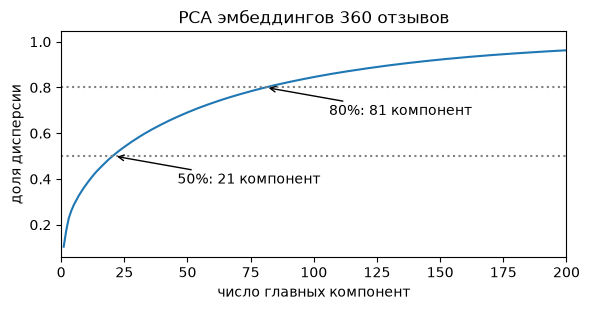

In [7]:
pca = PCA().fit(E)
cum = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.arange(1, len(cum) + 1), cum)
for share in [0.5, 0.8]:
    k = int(np.searchsorted(cum, share) + 1)
    ax.axhline(share, ls=":", color="gray")
    ax.annotate(f"{share:.0%}: {k} компонент", (k, share), (k + 25, share - 0.12), arrowprops={"arrowstyle": "->"})
ax.set(xlabel="число главных компонент", ylabel="доля дисперсии", title="PCA эмбеддингов 360 отзывов", xlim=(0, 200))
plt.tight_layout()
plt.show()

Хотя у векторов 1024 координаты, половину разброса объясняют несколько десятков направлений.
Эмбеддинги отзывов об одежде живут в пространстве гораздо меньшей размерности, чем кажется.

## 4. Карты: LSA, PCA, UMAP

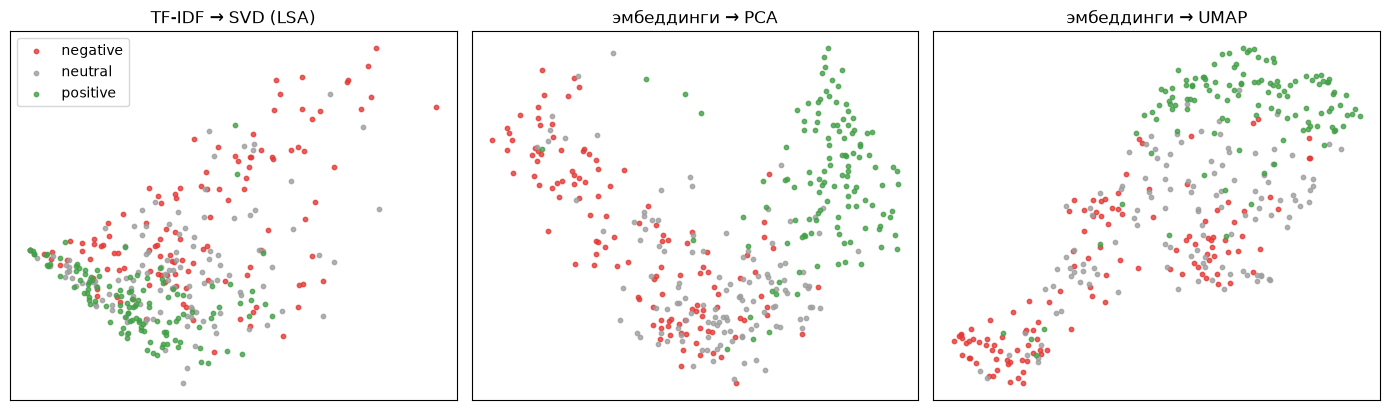

In [8]:
maps = {
    "TF-IDF → SVD (LSA)": TruncatedSVD(2, random_state=0).fit_transform(T),
    "эмбеддинги → PCA": PCA(2).fit_transform(E),
    "эмбеддинги → UMAP": umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=0,
                                   n_jobs=1).fit_transform(E),
}
colors = {"negative": "#E53935", "neutral": "#9E9E9E", "positive": "#43A047"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (title, xy) in zip(axes, maps.items()):
    for name, color in colors.items():
        m = labels == name
        ax.scatter(xy[m, 0], xy[m, 1], s=10, color=color, label=name, alpha=0.8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].legend()
plt.tight_layout()
plt.show()

На карте TF-IDF классы перекрываются сильнее всего: мешок слов плохо улавливает тональность
коротких текстов.
На картах эмбеддингов позитивные отзывы собираются в свою область, а негативные и нейтральные
частично перекрываются. Вспомним предупреждение из теории: расстояния и размеры «островов» на
UMAP не интерпретируются. Карта — повод для гипотезы, проверять будем числами.

## 5. k-means: сколько кластеров и что они значат

Для каждого $k$ посчитаем силуэт (насколько точки ближе к своему кластеру, чем к соседнему;
от −1 до 1) и ARI — совпадение кластеров с метками тональности.

In [9]:
rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(E)
    rows.append({"k": k, "силуэт": silhouette_score(E, km.labels_, metric="cosine"),
                 "ARI с тональностью": adjusted_rand_score(labels, km.labels_)})
pd.DataFrame(rows).set_index("k").round(3)

,силуэт,ARI с тональностью
k,,
2,0.139,0.352
3,0.143,0.381
4,0.120,0.307
5,0.126,0.272
6,0.108,0.267
7,0.092,0.207
8,0.061,0.178


Силуэт невелик при любом $k$: у текстов нет чётко разделённых «шаров», это нормально. Лучшее
значение — при малом $k$. Возьмём $k = 5$, чтобы увидеть больше тем, и посмотрим, что внутри
кластеров: размер, состав по тональности и слова, которые в кластере встречаются чаще, чем в среднем.

In [10]:
km = KMeans(n_clusters=5, n_init=10, random_state=0).fit(E)
overall = np.asarray(T.mean(axis=0)).ravel()
for c in range(5):
    m = km.labels_ == c
    lift = np.asarray(T[m].mean(axis=0)).ravel() - overall
    top_words = ", ".join(vocab[np.argsort(-lift)[:8]])
    mix = pd.Series(labels[m]).value_counts().reindex(list(colors), fill_value=0).to_dict()
    print(f"\n■ кластер {c}: {m.sum()} отзывов, {mix}\n  слова: {top_words}")
    for text in sample.text[m].head(2):
        print("  —", text[:110].replace("\n", " "))


■ кластер 0: 96 отзывов, {'negative': 1, 'neutral': 6, 'positive': 89}
  слова: спасибо, очень, доставка, быстро, хорошо, все, быстрая, супер
  — Оказалась мала, по мне качество не очень. Но очень быстрая доставка 
  — Заказ пришел быстро. я заказываю уже третью подобную кофточку.На этот раз черную. Но сейчас очень расстроена. 

■ кластер 1: 75 отзывов, {'negative': 32, 'neutral': 38, 'positive': 5}
  слова: нитки, торчат, качество, из, синтетика, отвратительное, выглядит, неприятный
  — Рукава вшиты неправильно. Носить невозможно. Блузку перекашивает.
  — Отвратительное качество. Пайетки осыпаются, бока тянут, проплешина, нитки торчат и плюс ко всему через всю пят

■ кластер 2: 70 отзывов, {'negative': 52, 'neutral': 14, 'positive': 4}
  слова: не, деньги, товар, вернули, пришёл, продавец, спор, заказ
  — Товар так и не получила. Продавец быстро вернул деньги
  — Заказ не пришел.  не успела открыть спор,  точнее открыла и по просьбе продавца и поверив его клятвенному обещ

■ кластер 

Кластеры — это **темы**: благодарность за быструю доставку, споры с продавцом и возврат денег,
качество ткани и швов, размеры. Тональность с темами связана лишь частично. За доставку почти всегда
хвалят, про споры почти всегда пишут негативно, а про размер пишут все. Поэтому ARI с тональностью
умеренный: k-means нашёл закономерность, но не ту, о которой мы его не спрашивали.

Так кластеризацию и применяют в AI-инженерии: разложить тысячи запросов пользователей или
документов для RAG по темам, найти неожиданные группы и «мусор».

## 6. Мост к обучению с учителем

Если метки есть, лучше их использовать. Сравним логистическую регрессию на TF-IDF и на эмбеддингах
на тех же 360 отзывах (5-fold CV).

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
acc_tfidf = cross_val_score(make_pipeline(TfidfVectorizer(min_df=2), LogisticRegression(max_iter=2000)),
                            np.array(texts), labels, cv=cv).mean()
acc_emb = cross_val_score(LogisticRegression(max_iter=2000), E, labels, cv=cv).mean()
print(f"TF-IDF + логрегрессия:      {acc_tfidf:.3f}")
print(f"эмбеддинги + логрегрессия:  {acc_emb:.3f}")
print(f"случайное угадывание:       {1 / 3:.3f}")

TF-IDF + логрегрессия:      0.642
эмбеддинги + логрегрессия:  0.753
случайное угадывание:       0.333


На маленькой выборке эмбеддинги выигрывают с большим отрывом: модель эмбеддингов уже «знает» язык,
и логистической регрессии остаётся провести границы в готовом пространстве. TF-IDF приходится
учить всё с нуля по 288 примерам. В M04 мы обучим классификаторы на всех 45 тысячах отзывов,
а в M11 разберём эмбеддинги подробно.

## ✅ Итоги

- Дубликаты, пересечения train/test и противоречивые метки проверяют до обучения.
- PCA показывает, что эмбеддинги живут в пространстве меньшей размерности. UMAP даёт карту,
  на которой ищут гипотезы, а не выводы.
- Силуэт помогает выбрать $k$, ARI сравнивает кластеры с известными метками.
- k-means находит темы, а не обязательно то, что нас интересует. Смысл кластеров проверяют
  по словам и примерам.
- Эмбеддинги + простая модель — сильный baseline для классификации текстов при малом числе примеров.

✍️ **Упражнение:** `exercises/ex04_kmeans.py` — k-means и силуэт с нуля.